## Sprint 1 – Exploratory Data Analysis & Preprocessing

This notebook explores the image dataset structure, class distribution,
and basic image preprocessing techniques required before model training.

## Environment Notes

This notebook was executed using Python 3.10.

Required libraries:
- numpy
- matplotlib
- Pillow
- opencv-python

Any Python 3.9–3.11 environment with these libraries installed will run this notebook.


Main folders: ['Toilets', 'Seat Cover']
Seat Cover - Elongated: 95 images


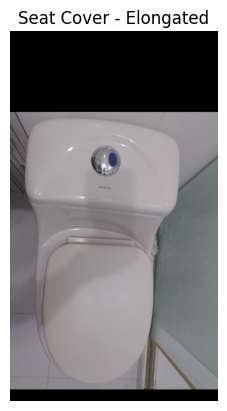

Seat Cover - Round: 73 images


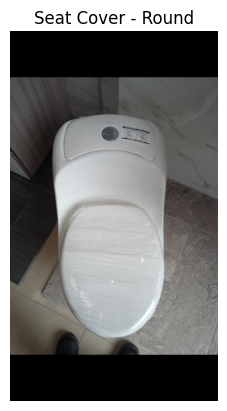

Toilet - Smart: 316 images


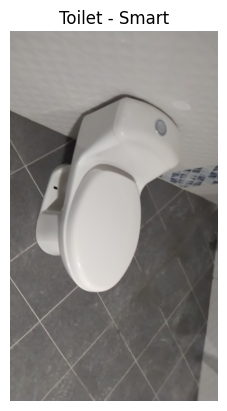

Toilet - Aquapro: 292 images


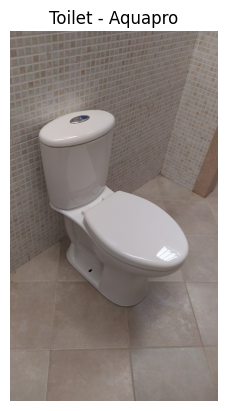

Toilet - Montecarlo: 334 images


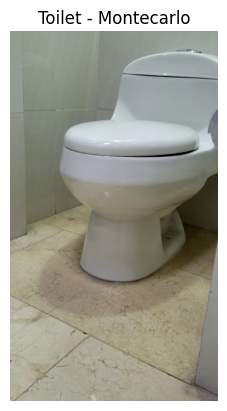

In [1]:
# Exploratory data analysis: dataset structure and sample images

import os
import matplotlib.pyplot as plt
from PIL import Image

DATASET_ROOT = "data/raw"

def eda_image_dataset(dataset_path):
    main_folders = [
        f for f in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, f))
    ]
    print("Main folders:", main_folders)

    # Seat Cover
    if "Seat Cover" in main_folders:
        seat_cover_path = os.path.join(dataset_path, "Seat Cover")
        seat_shapes = [
            s for s in os.listdir(seat_cover_path)
            if os.path.isdir(os.path.join(seat_cover_path, s))
        ]

        for shape in seat_shapes:
            shape_path = os.path.join(seat_cover_path, shape)
            images = [
                img for img in os.listdir(shape_path)
                if img.lower().endswith((".jpg", ".png", ".jpeg"))
            ]
            print(f"Seat Cover - {shape}: {len(images)} images")

            if images:
                img = Image.open(os.path.join(shape_path, images[0]))
                plt.imshow(img)
                plt.title(f"Seat Cover - {shape}")
                plt.axis("off")
                plt.show()

    # Toilets
    if "Toilets" in main_folders:
        toilets_path = os.path.join(dataset_path, "Toilets")
        toilet_types = [
            t for t in os.listdir(toilets_path)
            if os.path.isdir(os.path.join(toilets_path, t))
        ]

        for toilet_type in toilet_types:
            type_path = os.path.join(toilets_path, toilet_type)
            images = [
                img for img in os.listdir(type_path)
                if img.lower().endswith((".jpg", ".png", ".jpeg"))
            ]
            print(f"Toilet - {toilet_type}: {len(images)} images")

            if images:
                img = Image.open(os.path.join(type_path, images[0]))
                plt.imshow(img)
                plt.title(f"Toilet - {toilet_type}")
                plt.axis("off")
                plt.show()


# Run EDA
eda_image_dataset(DATASET_ROOT)


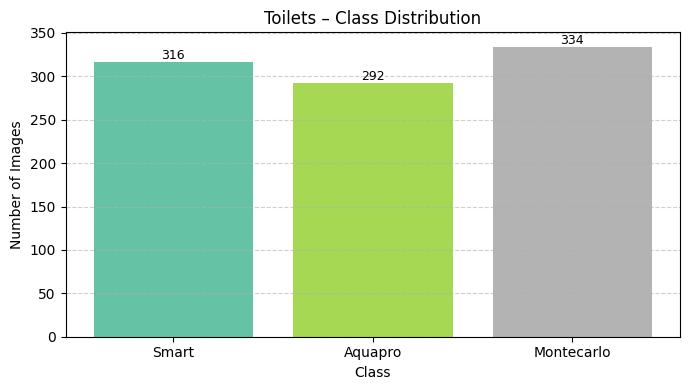

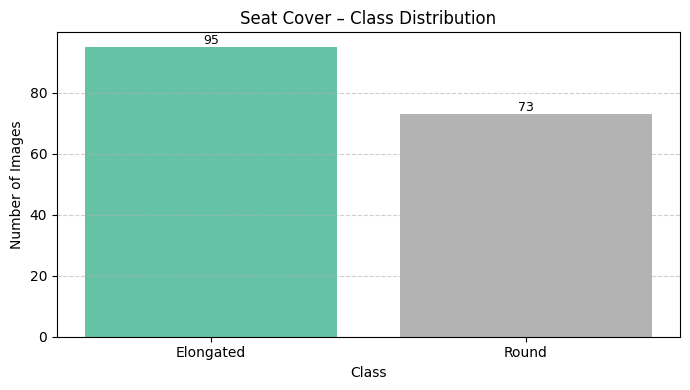

In [2]:
# EDA: class-wise image distribution

import os
import matplotlib.pyplot as plt
import numpy as np

DATASET_ROOT = "data/raw"

folders = {"Toilets": {}, "Seat Cover": {}}

# Collect image counts
for main_cat in folders:
    main_path = os.path.join(DATASET_ROOT, main_cat)
    subfolders = [
        f for f in os.listdir(main_path)
        if os.path.isdir(os.path.join(main_path, f))
    ]

    for sub in subfolders:
        sub_path = os.path.join(main_path, sub)
        imgs = [
            i for i in os.listdir(sub_path)
            if i.lower().endswith(("jpg", "png", "jpeg"))
        ]
        folders[main_cat][sub] = len(imgs)

# Visualization
for category, counts in folders.items():
    plt.figure(figsize=(7, 4))

    classes = list(counts.keys())
    values = list(counts.values())
    colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))

    bars = plt.bar(classes, values, color=colors)
    plt.title(f"{category} – Class Distribution")
    plt.ylabel("Number of Images")
    plt.xlabel("Class")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval,
            yval,
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


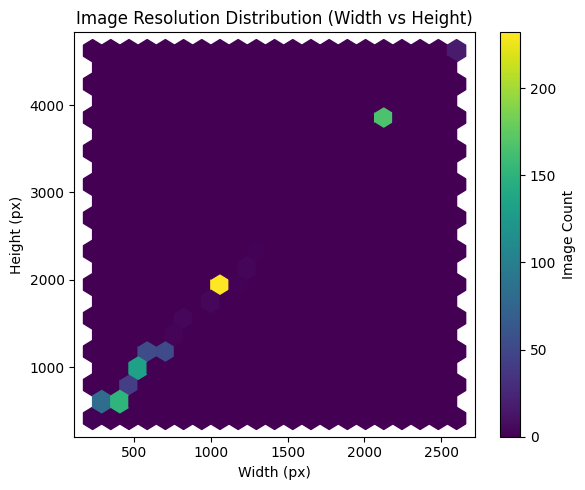

In [3]:
# Image resolution analysis (width vs height)

from PIL import Image
import numpy as np

def get_image_shapes(folder_path):
    shapes = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('jpg', 'png', 'jpeg')):
            img_path = os.path.join(folder_path, filename)
            with Image.open(img_path) as img:
                shapes.append(img.size)  # (width, height)
    return shapes


all_shapes = []
main_cat = 'Toilets'
toilet_types = [
    t for t in os.listdir(os.path.join(DATASET_ROOT, main_cat))
    if os.path.isdir(os.path.join(DATASET_ROOT, main_cat, t))
]

for t in toilet_types:
    path = os.path.join(DATASET_ROOT, main_cat, t)
    all_shapes.extend(get_image_shapes(path))

widths, heights = zip(*all_shapes)

plt.figure(figsize=(6, 5))
plt.hexbin(widths, heights, gridsize=20, cmap="viridis")
plt.colorbar(label="Image Count")
plt.title("Image Resolution Distribution (Width vs Height)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.tight_layout()
plt.show()



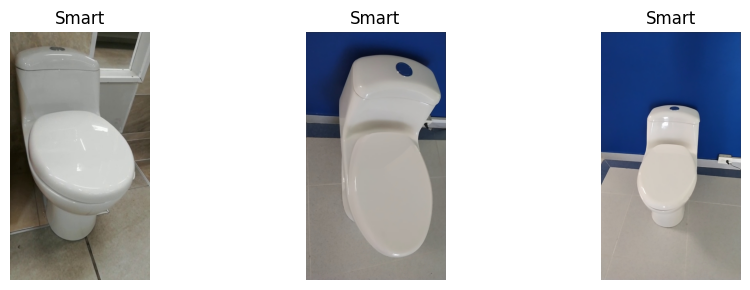

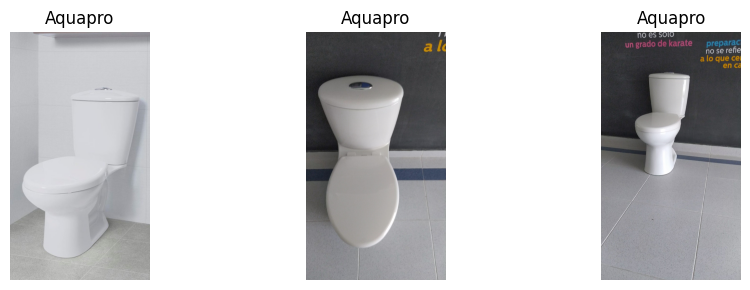

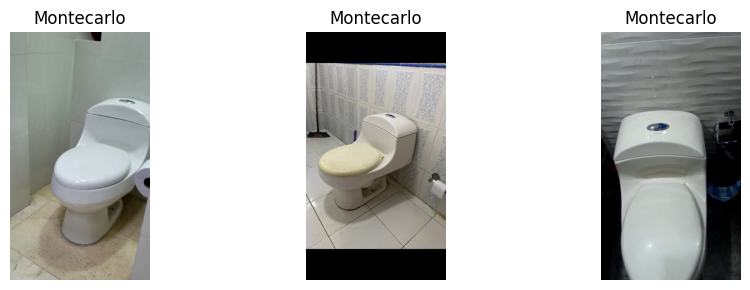

In [4]:
# Visual inspection: random sample images per toilet class

import random

def display_random_images(class_path, class_name, n=3):
    imgs = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(("jpg", "png", "jpeg"))
    ]
    
    if len(imgs) == 0:
        return

    sample_imgs = random.sample(imgs, min(n, len(imgs)))

    plt.figure(figsize=(10, 3))
    for i, img_file in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Samples per toilet type
for t in toilet_types:
    display_random_images(
        os.path.join(DATASET_ROOT, main_cat, t),
        class_name=t,
        n=3
    )



In [5]:
# Data quality check: corrupt or unusually small images

def check_bad_images(folder_path):
    found_issue = False
    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(('jpg', 'png', 'jpeg')):
                img_path = os.path.join(root, f)
                try:
                    with Image.open(img_path) as img:
                        if min(img.size) < 32:
                            print(f"Small image detected: {img_path}")
                            found_issue = True
                except Exception as e:
                    print(f"Cannot open image: {img_path}, Error: {str(e)}")
                    found_issue = True

    if not found_issue:
        print("No corrupt or unusually small images found.")


check_bad_images(DATASET_ROOT)


No corrupt or unusually small images found.


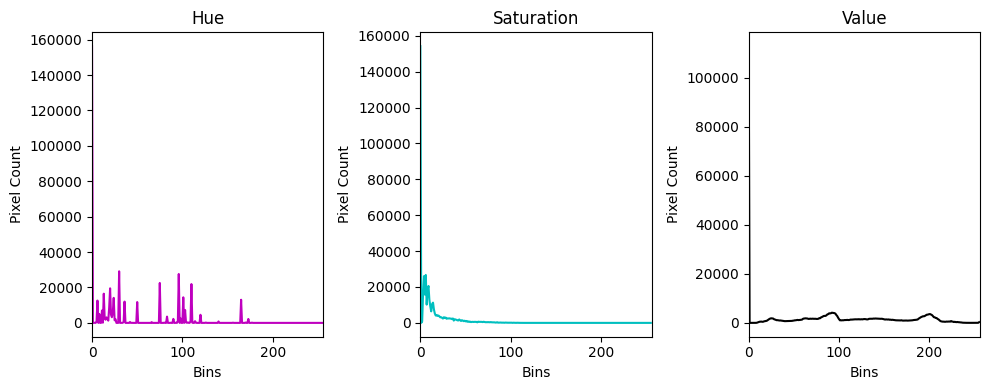

In [6]:
# Color distribution analysis using HSV 

import cv2
import matplotlib.pyplot as plt
import os

def plot_hsv_histograms(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    channels = cv2.split(hsv)
    titles = ["Hue", "Saturation", "Value"]
    colors = ["m", "c", "k"]

    plt.figure(figsize=(10, 4))
    for i, (chan, title, color) in enumerate(zip(channels, titles, colors)):
        plt.subplot(1, 3, i + 1)
        hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.title(title)
        plt.xlabel("Bins")
        plt.ylabel("Pixel Count")
        plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()


# Sample image from Seat Cover / Round
sample_folder = os.path.join(DATASET_ROOT, "Seat Cover", "Round")
imgs = [f for f in os.listdir(sample_folder) if f.lower().endswith(("jpg","png","jpeg"))]

if imgs:
    plot_hsv_histograms(os.path.join(sample_folder, imgs[0]))


Round: original size = (896, 504)
Elongated: original size = (896, 504)
Aquapro: original size = (3840, 2160)
Smart: original size = (1920, 1080)
Montecarlo: original size = (500, 281)


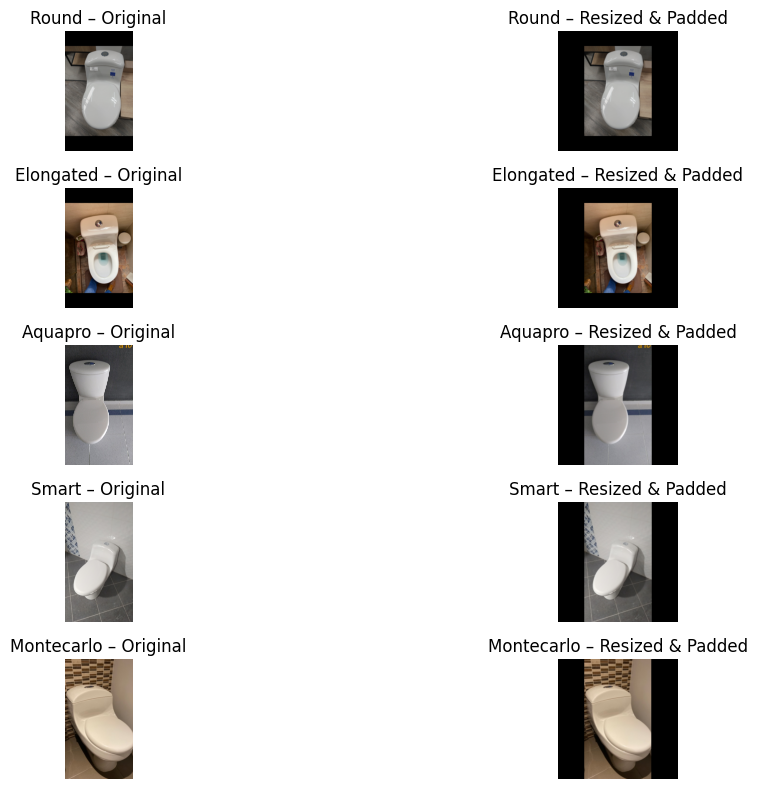

In [7]:
# Image preprocessing: resizing and padding for uniform input size

import cv2
import matplotlib.pyplot as plt
import os
import random

def resize_and_pad(img, size=256, pad_color=0):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(h * scale), int(w * scale)

    img_resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)

    top = (size - nh) // 2
    bottom = size - nh - top
    left = (size - nw) // 2
    right = size - nw - left

    img_padded = cv2.copyMakeBorder(
        img_resized,
        top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=pad_color
    )

    return img_resized, img_padded


# Define image class folders
image_classes = {
    "Round": os.path.join(DATASET_ROOT, "Seat Cover", "Round"),
    "Elongated": os.path.join(DATASET_ROOT, "Seat Cover", "Elongated"),
    "Aquapro": os.path.join(DATASET_ROOT, "Toilets", "Aquapro"),
    "Smart": os.path.join(DATASET_ROOT, "Toilets", "Smart"),
    "Montecarlo": os.path.join(DATASET_ROOT, "Toilets", "Montecarlo")
}

plt.figure(figsize=(15, 8))
plot_pos = 1

for class_name, folder in image_classes.items():
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('jpg', 'jpeg', 'png'))
    ]

    if not files:
        continue

    sample_file = random.choice(files)
    img_path = os.path.join(folder, sample_file)

    img = cv2.imread(img_path)
    print(f"{class_name}: original size = {img.shape[:2]}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    _, img_padded = resize_and_pad(img, size=256, pad_color=(0, 0, 0))
    img_padded_rgb = cv2.cvtColor(img_padded, cv2.COLOR_BGR2RGB)

    # Original image
    plt.subplot(len(image_classes), 2, plot_pos)
    plt.imshow(img_rgb)
    plt.title(f"{class_name} – Original")
    plt.axis("off")
    plot_pos += 1

    # Resized + padded image
    plt.subplot(len(image_classes), 2, plot_pos)
    plt.imshow(img_padded_rgb)
    plt.title(f"{class_name} – Resized & Padded")
    plt.axis("off")
    plot_pos += 1

plt.tight_layout()
plt.show()


In [8]:
print("Dataset root contents:", os.listdir(DATASET_ROOT))

Dataset root contents: ['.DS_Store', 'Toilets', 'Seat Cover']


## Image Augmentation

Based on class imbalance and visual variability observed during EDA,
image augmentation is applied to increase data diversity while preserving
the semantic meaning of the objects.


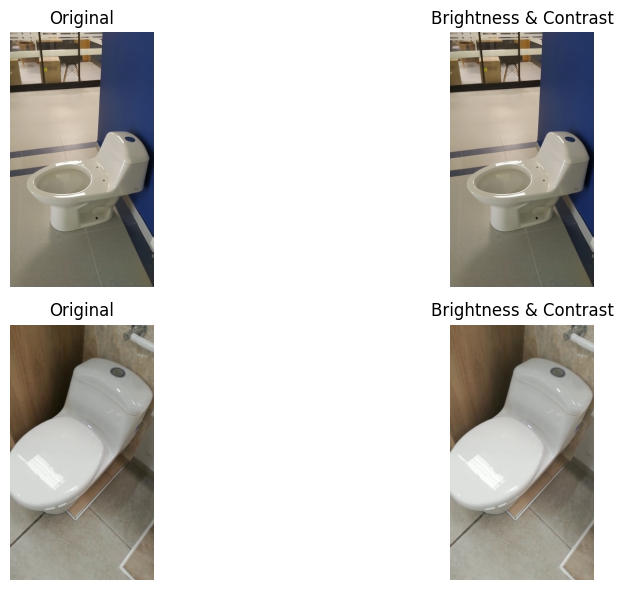

In [9]:
# Image augmentation: subtle brightness and contrast

import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import random

folder = os.path.join(DATASET_ROOT, "Toilets", "Smart")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

sample_imgs = random.sample(images, 2)

# Augmentation
transform = A.RandomBrightnessContrast(
    brightness_limit=0.15,
    contrast_limit=0.15,
    p=1.0
)

plt.figure(figsize=(12, 6))
plot_pos = 1

for img_file in sample_imgs:
    img_path = os.path.join(folder, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = transform(image=img_rgb)["image"]

    plt.subplot(2, 2, plot_pos)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")
    plot_pos += 1

    plt.subplot(2, 2, plot_pos)
    plt.imshow(augmented)
    plt.title("Brightness & Contrast")
    plt.axis("off")
    plot_pos += 1

plt.tight_layout()
plt.show()


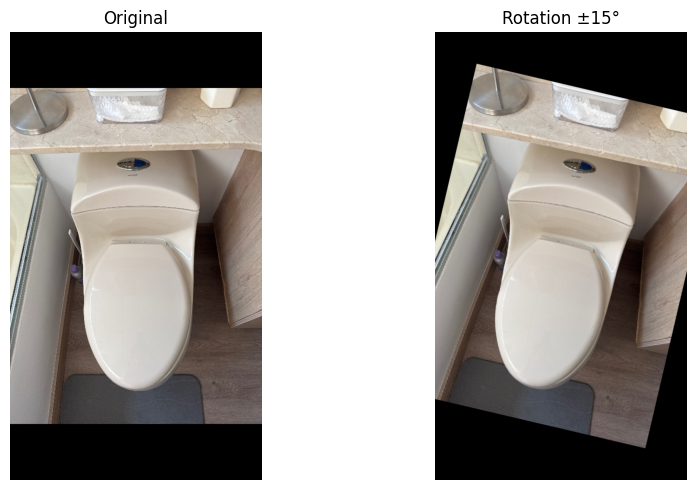

In [10]:
# Image augmentation: small rotation (±15 degrees)

import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import random

# Random image from Seat Cover / Elongated
folder = os.path.join(DATASET_ROOT, "Seat Cover", "Elongated")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

img_path = os.path.join(folder, random.choice(images))
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Small rotation augmentation
transform = A.Rotate(limit=15, p=1.0)
augmented = transform(image=img_rgb)["image"]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title("Rotation ±15°")
plt.axis("off")

plt.tight_layout()
plt.show()


/opt/anaconda3/envs/sprint2-cnn/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


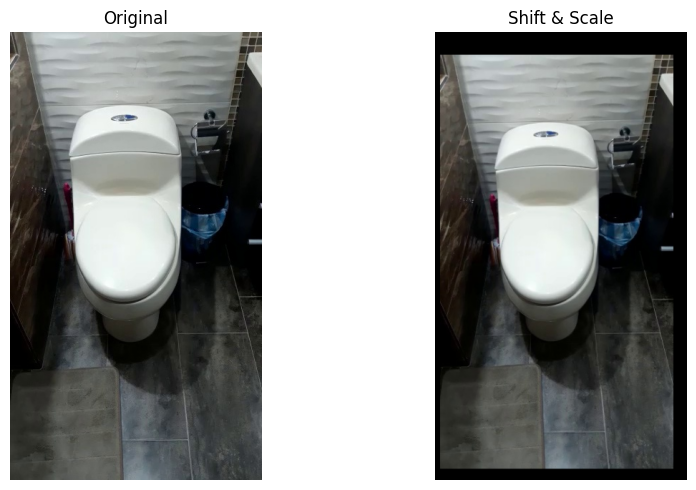

In [11]:
# Image augmentation: shift and scale 

import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os
import random

# Random image from Toilets / Montecarlo
folder = os.path.join(DATASET_ROOT, "Toilets", "Montecarlo")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

img_path = os.path.join(folder, random.choice(images))
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Shift and scale 
transform = A.ShiftScaleRotate(
    shift_limit=0.05,
    scale_limit=0.1,
    rotate_limit=0,
    p=1.0
)

augmented = transform(image=img_rgb)["image"]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title("Shift & Scale")
plt.axis("off")

plt.tight_layout()
plt.show()

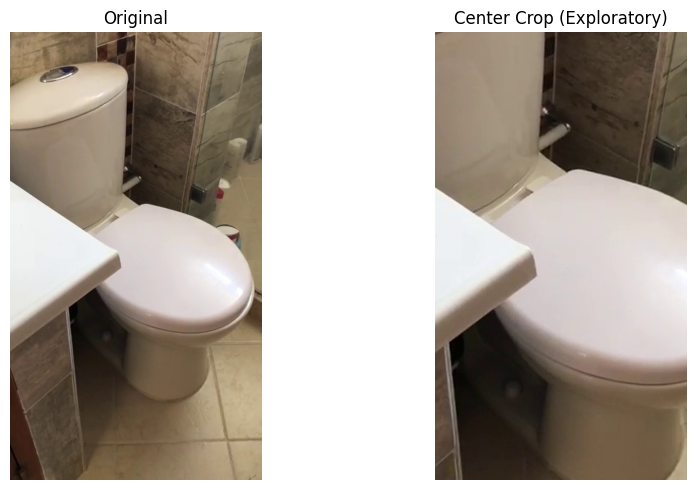

In [12]:
# Exploratory preprocessing: center cropping (only demo- not used in training)

import cv2
import matplotlib.pyplot as plt
import os
import random

# Random image from Toilets / Aquapro
folder = os.path.join(DATASET_ROOT, "Toilets", "Aquapro")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

img_path = os.path.join(folder, random.choice(images))
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Center crop (demo only, not used for training)
h, w = img.shape[:2]
crop = img[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(crop_rgb)
plt.title("Center Crop (Exploratory)")
plt.axis("off")

plt.tight_layout()
plt.show()


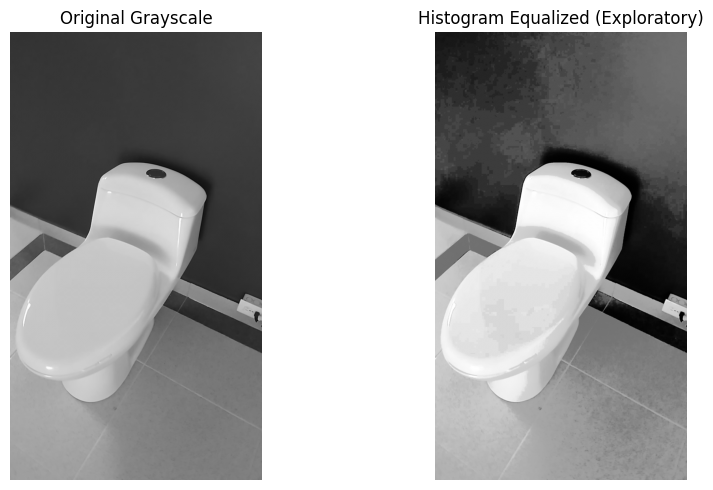

In [13]:
# Exploratory preprocessing: histogram equalization 

import cv2
import matplotlib.pyplot as plt
import os
import random

# Random image from Toilets / Smart
folder = os.path.join(DATASET_ROOT, "Toilets", "Smart")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

img_path = os.path.join(folder, random.choice(images))
img = cv2.imread(img_path)

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Histogram equalization
img_eq = cv2.equalizeHist(img_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_eq, cmap="gray")
plt.title("Histogram Equalized (Exploratory)")
plt.axis("off")

plt.tight_layout()
plt.show()


# Sprint 2 – CNN from Scratch

**Objective:**  
Build and evaluate two CNNs (Seat Cover & Toilets) from scratch,  
compare training **with and without image augmentation**,  
and analyze misclassified images.

**Sprint-2 Scope:**  
- Aspect-ratio preserving preprocessing with padding  
- CNN from scratch  
- Augmentation comparison  
- Evaluation & error analysis


In [25]:
import torch

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: mps


In [14]:
import os
import cv2
import random
import matplotlib.pyplot as plt

DATASET_ROOT = "data/raw"


(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

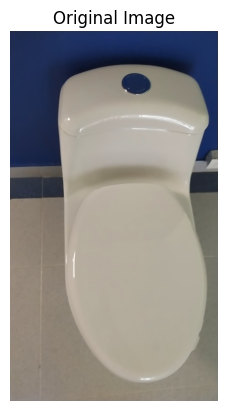

In [15]:
folder = os.path.join(DATASET_ROOT, "Toilets", "Smart")
images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

img_path = os.path.join(folder, random.choice(images))
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")


## Preprocessing: Resize with Aspect Ratio Preservation

Images in the dataset vary in size and aspect ratio.  
To ensure consistent CNN input without geometric distortion,  
images are resized while preserving aspect ratio and padded to a fixed size.


In [16]:
def resize_with_padding(image, target_size=(224, 224), pad_color=(0, 0, 0)):
    target_h, target_w = target_size
    h, w = image.shape[:2]

    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    pad_w = target_w - new_w
    pad_h = target_h - new_h

    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    padded = cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=pad_color
    )

    return padded


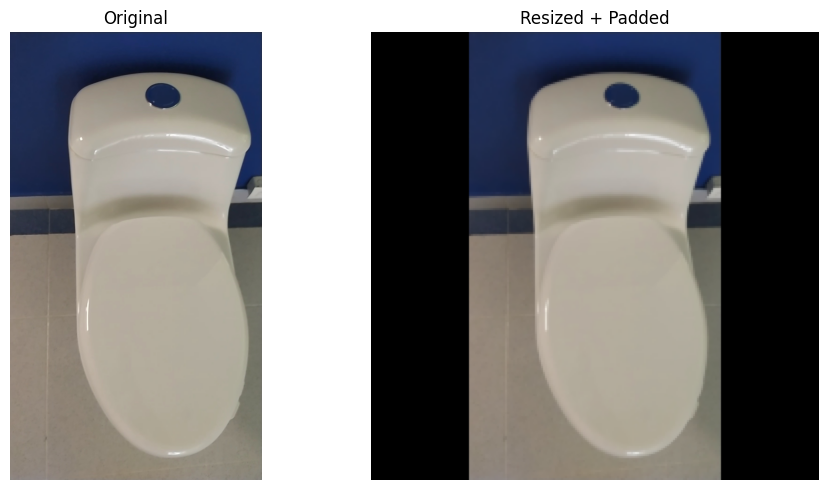

In [17]:
processed = resize_with_padding(img_rgb)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Resized + Padded")
plt.axis("off")

plt.tight_layout()
plt.show()


## Data Organization: Train / Validation / Test Split

After fixing preprocessing, the dataset is split into train, validation, and test sets.
The same split is reused for all experiments to ensure fair comparison.


In [18]:
import os
import shutil
import random

DATASET_ROOT = "data/raw"
SPLIT_ROOT = "data/splits"
SPLIT_RATIO = (0.7, 0.15, 0.15)

random.seed(42)

def split_data(src_root, dst_root):
    # ---- SAFETY GUARD ----
    if os.path.exists(dst_root):
        print(f"Splits already exist at {dst_root}. Skipping.")
        return

    print(f"Creating splits at {dst_root}...")

    for cls in os.listdir(src_root):
        cls_path = os.path.join(src_root, cls)
        if not os.path.isdir(cls_path):
            continue

        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * SPLIT_RATIO[0])
        n_val = int(n * SPLIT_RATIO[1])

        splits = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split, files in splits.items():
            out_dir = os.path.join(dst_root, split, cls)
            os.makedirs(out_dir, exist_ok=True)

            for f in files:
                shutil.copy(
                    os.path.join(cls_path, f),
                    os.path.join(out_dir, f)
                )

    print("Splits created.")


# Seat Cover
split_data(
    os.path.join(DATASET_ROOT, "Seat Cover"),
    os.path.join(SPLIT_ROOT, "seat_cover")
)

# Toilets
split_data(
    os.path.join(DATASET_ROOT, "Toilets"),
    os.path.join(SPLIT_ROOT, "toilets")
)


Splits already exist at data/splits/seat_cover. Skipping.
Splits already exist at data/splits/toilets. Skipping.


## CNN Architecture (From Scratch)


In [19]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # adaptive pooling avoids shape bugs
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


## Training Configuration (Baseline)


In [ ]:
# CNN MODEL + TRAINING SETUP

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# config
EPOCHS = 5
BATCH_SIZE = 32
LR = 1e-3

# basic transform (baseline = no augmentation)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# datasets (reuse existing splits on disk)
train_dataset = datasets.ImageFolder(
    root="data/splits/seat_cover/train",
    transform=base_transform
)

val_dataset = datasets.ImageFolder(
    root="data/splits/seat_cover/val",
    transform=base_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# model
model = SimpleCNN(num_classes=len(train_dataset.classes)).to(DEVICE)

# loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("Setup complete")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", train_dataset.classes)


Setup complete
Train samples: 117
Val samples: 24
Classes: ['Elongated', 'Round']


### Seat Cover | No Augmentation


In [21]:
print("BASELINE TRAINING STARTED (No Augmentation)")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")


BASELINE TRAINING STARTED (No Augmentation)
Epoch 1/5 | Loss: 0.6934 | Val Acc: 0.5833
Epoch 2/5 | Loss: 0.6852 | Val Acc: 0.5833
Epoch 3/5 | Loss: 0.6855 | Val Acc: 0.5833
Epoch 4/5 | Loss: 0.6839 | Val Acc: 0.5833
Epoch 5/5 | Loss: 0.6926 | Val Acc: 0.5833


In [22]:
from torchvision import transforms

aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor()
])


In [23]:
# ===== AUGMENTED SETUP =====

train_dataset_aug = datasets.ImageFolder(
    root="data/splits/seat_cover/train",
    transform=aug_transform
)

val_dataset_aug = datasets.ImageFolder(
    root="data/splits/seat_cover/val",
    transform=base_transform   # validation NEVER augmented
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# fresh model
model_aug = SimpleCNN(num_classes=len(train_dataset_aug.classes)).to(DEVICE)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR)

print("Augmented setup complete")


Augmented setup complete


In [24]:
print("AUGMENTED TRAINING STARTED")

for epoch in range(EPOCHS):
    model_aug.train()
    running_loss = 0.0

    for imgs, labels in train_loader_aug:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer_aug.zero_grad()
        outputs = model_aug(imgs)
        loss = criterion_aug(outputs, labels)
        loss.backward()
        optimizer_aug.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader_aug)

    model_aug.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader_aug:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model_aug(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")


AUGMENTED TRAINING STARTED
Epoch 1/5 | Loss: 0.6863 | Val Acc: 0.5833
Epoch 2/5 | Loss: 0.6889 | Val Acc: 0.5833
Epoch 3/5 | Loss: 0.6869 | Val Acc: 0.5833
Epoch 4/5 | Loss: 0.6879 | Val Acc: 0.5833
Epoch 5/5 | Loss: 0.6832 | Val Acc: 0.5833
